# 2-Triangle Computation — Working Cases + Complex-Case Optimization

Two parts:

1. **Visualize the computation on *valid* fields.** Uses `plot_triangle_debug` to render the warped-grid neighborhood, both T1/T2 triangles outlined, and the full formula/input text panel on deformations where every triangle is positive (red in the workspace `RdBu_r` palette). Shows what a healthy per-pixel inspection looks like — contrast to the bowtie failure case in `02_optimization.ipynb`.
2. **2-triangle SLSQP optimization on the `test_cases` fold library.** Runs the new 2-triangle constraint on non-trivial synthetic folds (10×10 crossings, 20×20 opposite motions, 20×40 edge discontinuities) and reports neg-count reduction vs. two Jacobian baselines side-by-side:
   - **Central-difference Jdet** (`jacobian_det2D`) — symmetric `np.gradient` stencil, per pixel.
   - **Forward-difference Jdet** — one-sided forward stencil, per *cell* (TL corner).

Both are finite-difference Jacobians but with different stencils; comparing them shows how much the per-cell forward-diff already recovers vs. the per-pixel central stencil, and where the 2-triangle check is stricter than either.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_det2D, triangle_sign_areas2D
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.core.objective import objective_euc
from dvfopt.viz import plot_triangle_debug

from test_cases import make_deformation

THRESHOLD = DEFAULT_PARAMS['threshold']  # 0.01
print(f'threshold = {THRESHOLD}')


def _forward_jdet_2d(dy, dx):
    """Per-cell Jacobian determinant via forward finite differences.

    Returns shape ``(H-1, W-1)``. Each cell is anchored at its TL corner:

        ∂dx/∂x ≈ dx[y, x+1] - dx[y, x]
        ∂dy/∂y ≈ dy[y+1, x] - dy[y, x]
        ∂dx/∂y ≈ dx[y+1, x] - dx[y, x]
        ∂dy/∂x ≈ dy[y, x+1] - dy[y, x]
        Jdet   = (1 + ∂dx/∂x)(1 + ∂dy/∂y) - (∂dx/∂y)(∂dy/∂x)
    """
    ddx_dx = dx[:-1, 1:]  - dx[:-1, :-1]
    ddy_dy = dy[1:,  :-1] - dy[:-1, :-1]
    ddx_dy = dx[1:,  :-1] - dx[:-1, :-1]
    ddy_dx = dy[:-1, 1:]  - dy[:-1, :-1]
    return (1 + ddx_dx) * (1 + ddy_dy) - ddx_dy * ddy_dx

threshold = 0.01


## Part 1 — Working (positive) triangles

We pick four kinds of valid (no-fold) deformation and use `plot_triangle_debug(phi, x, y)` to inspect one interior pixel per case. In every case both T1 and T2 should be positive: the triangle fills red under the workspace `RdBu_r` convention, and the right-hand text panel shows how the area is built from the per-vertex (ref, δ, ε, warped) coordinates and the `AB × AC` cross product.

### 1a. Identity deformation

`dx = dy = 0`. Every triangle has signed area exactly `+0.5` — the raw cross product for a half-unit right triangle under the +y-down convention is `−1`, negated in the formula.

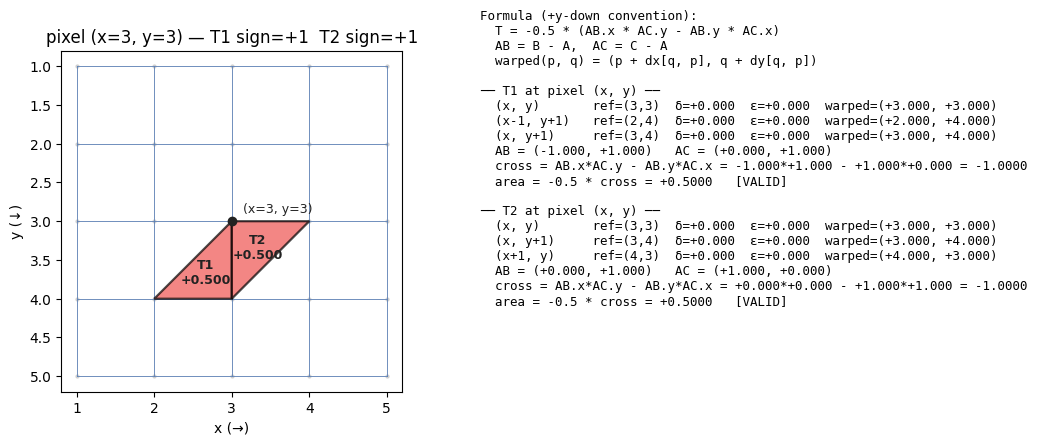

In [2]:
H = W = 7
phi_identity = np.zeros((2, H, W))

_ = plot_triangle_debug(phi_identity, x=3, y=3)

### 1b. Uniform translation

Constant displacement: `dx = +0.35, dy = −0.2` everywhere. Every pixel moves by the same vector so the warped grid is just a shifted copy of the reference grid. Relative vertex positions `AB`, `AC` are unchanged ⇒ same `+0.5` area, same sign.

all T1 sign: [1]
all T2 sign: [1]


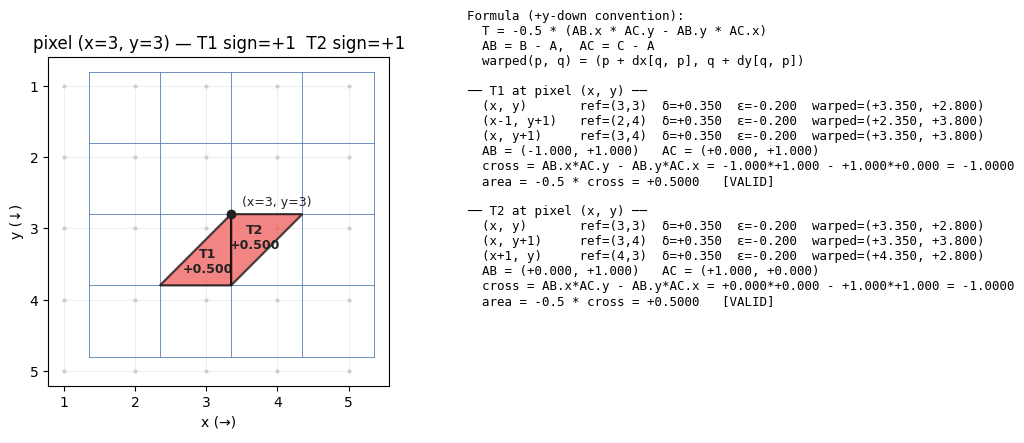

In [3]:
dy_t = np.full((H, W), -0.2)
dx_t = np.full((H, W), +0.35)
phi_translation = np.stack([dy_t, dx_t])

print('all T1 sign:', np.unique(triangle_sign_det2D(phi_translation)[0]))
print('all T2 sign:', np.unique(triangle_sign_det2D(phi_translation)[1]))
_ = plot_triangle_debug(phi_translation, x=3, y=3)

### 1c. Gentle uniform scale

`dx[y, x] = 0.15·x, dy[y, x] = 0.15·y` stretches the grid by a factor of 1.15 in both axes. Every triangle remains positive but grows by `(1.15)² ≈ 1.32` (so ~`+0.66` instead of `+0.5`). The text panel lets you read off exactly which vertex picks up which displacement.

scale  : min tri area=+0.6612   max tri area=+0.6613   all positive=True


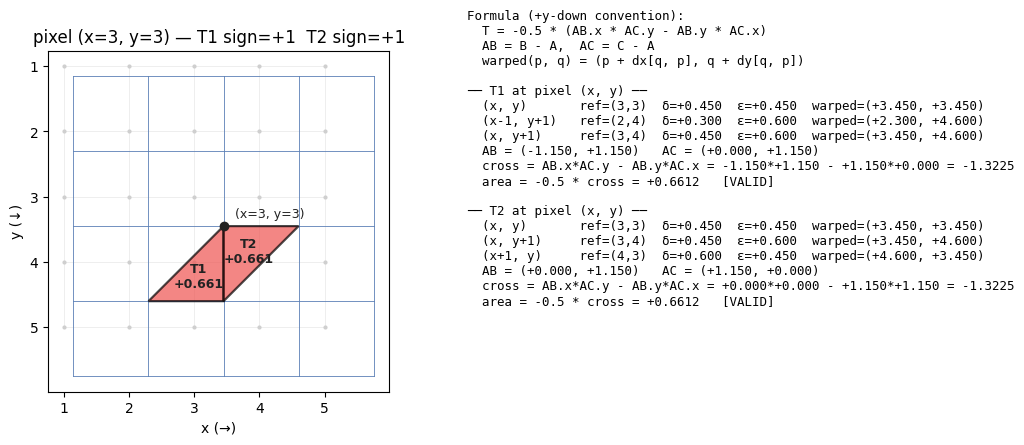

In [4]:
yy, xx = np.mgrid[:H, :W].astype(float)
dx_s = 0.15 * xx
dy_s = 0.15 * yy
phi_scale = np.stack([dy_s, dx_s])

tri = triangle_sign_areas2D(phi_scale)
print(f'scale  : min tri area={tri.min():+.4f}   max tri area={tri.max():+.4f}   all positive={(tri > 0).all()}')
_ = plot_triangle_debug(phi_scale, x=3, y=3)

### 1d. Small rotation about the grid center

15° rotation — both `dx` and `dy` become spatially varying so the text panel shows every vertex picking up a different `(δ, ε)`. Still valid: orientation-preserving rigid motion keeps every triangle positive.

rotation: min tri area=+0.5000   max tri area=+0.5000   all positive=True


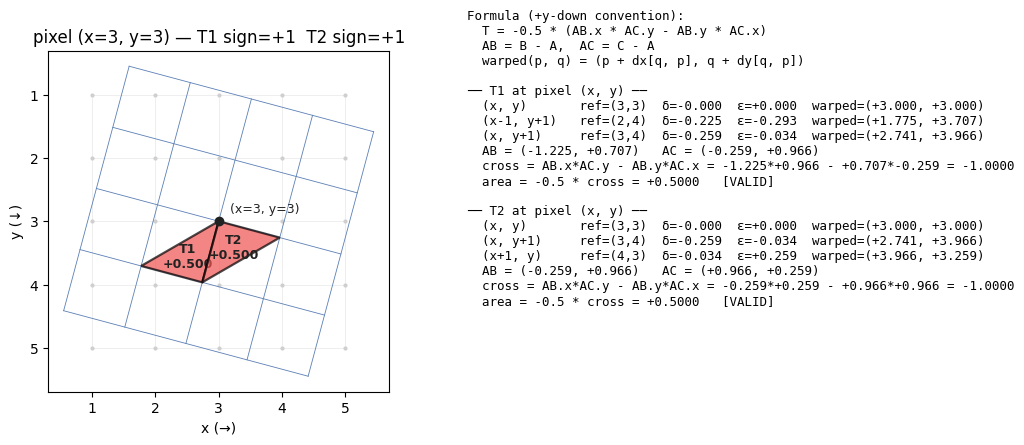

In [5]:
theta = np.deg2rad(15.0)
cx, cy = (W - 1) / 2, (H - 1) / 2
dx_r = (xx - cx) * (np.cos(theta) - 1) - (yy - cy) * np.sin(theta)
dy_r = (xx - cx) * np.sin(theta) + (yy - cy) * (np.cos(theta) - 1)
phi_rotation = np.stack([dy_r, dx_r])

tri = triangle_sign_areas2D(phi_rotation)
print(f'rotation: min tri area={tri.min():+.4f}   max tri area={tri.max():+.4f}   all positive={(tri > 0).all()}')
_ = plot_triangle_debug(phi_rotation, x=3, y=3)

### 1e. Small random deformation

Gaussian-noise displacement with `σ = 0.08`. Low enough that every triangle stays positive; showcases the realistic case where the formula is non-trivial and the text panel gives useful debugging info.

random  : min tri area=+0.3356   max tri area=+0.6595   all positive=True
worst cell at (y=1, x=3), min area=+0.3356


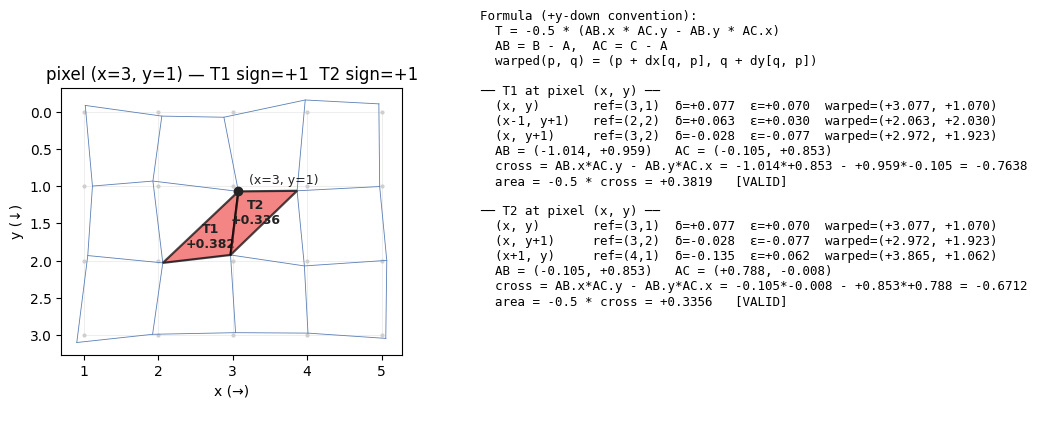

In [6]:
rng = np.random.default_rng(42)
dy_n = rng.normal(scale=0.08, size=(H, W))
dx_n = rng.normal(scale=0.08, size=(H, W))
phi_noise = np.stack([dy_n, dx_n])

tri = triangle_sign_areas2D(phi_noise)
print(f'random  : min tri area={tri.min():+.4f}   max tri area={tri.max():+.4f}   all positive={(tri > 0).all()}')

# Pick the pixel whose min(T1, T2) is smallest — tightest constraint in this realization.
tri_min = tri.min(axis=0)
cy_worst, cx_worst = np.unravel_index(tri_min.argmin(), tri_min.shape)
print(f'worst cell at (y={cy_worst}, x={cx_worst}), min area={tri_min[cy_worst, cx_worst]:+.4f}')
_ = plot_triangle_debug(phi_noise, x=cx_worst, y=cy_worst)

## Part 2 — 2-triangle SLSQP on the `test_cases` fold library

Six synthetic folds of increasing scale:

| key | grid | fold style |
|---|---|---|
| `01a_10x10_crossing` | 10×10 | small crossing |
| `01b_10x10_opposite` | 10×10 | small opposite-motion |
| `03b_10x10_crossing` | 10×10 | larger-magnitude crossing |
| `03c_20x20_opposite` | 20×20 | medium opposite |
| `03d_20x20_crossing` | 20×20 | 20×20 crossing (dense folds) |
| `01c_20x40_edges` | 20×40 | edge-localized fold |

For each, full-grid SLSQP with `NonlinearConstraint(triangle_signed_areas ≥ threshold)`, pack `z = [dx_flat | dy_flat]`, quadratic data term. The table reports neg-counts under central-diff (CD, per pixel), forward-diff (FD, per cell), and 2-triangle (TR) measures before and after correction.

In [7]:
from dvfopt.jacobian.intersection import (
    has_quad_self_intersections,
    _quads_intersect,
)


def _triangle_flat(dy_, dx_):
    T1, T2 = _triangle_areas_2d(dy_, dx_)
    return np.concatenate([T1.flatten(), T2.flatten()])

def run_slsqp_2tri(phi_init, threshold=THRESHOLD, max_iter=500):
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    dy_i, dx_i = phi_init[0], phi_init[1]
    z0 = np.concatenate([dx_i.flatten(), dy_i.flatten()])
    z0_init = z0.copy()

    def unpack(z):
        dx_ = z[:pixels].reshape(H_, W_)
        dy_ = z[pixels:].reshape(H_, W_)
        return dy_, dx_

    t0 = time.time()
    res = minimize(
        lambda z: objective_euc(z, z0_init),
        z0,
        jac=True,
        method='SLSQP',
        constraints=[NonlinearConstraint(
            lambda z: _triangle_flat(*unpack(z)),
            threshold, np.inf,
        )],
        options={'maxiter': max_iter, 'disp': False},
    )
    elapsed = time.time() - t0
    dy_o, dx_o = unpack(res.x)
    phi_out = np.stack([dy_o, dx_o])
    return phi_out, dict(nit=res.nit, time=elapsed, success=bool(res.success),
                         message=str(res.message), status=int(res.status))

def measure(phi):
    jd = np.squeeze(jacobian_det2D(phi))          # central-diff, (H, W)
    fd = _forward_jdet_2d(phi[0], phi[1])          # forward-diff, (H-1, W-1)
    tri = triangle_sign_areas2D(phi)               # 2-triangle,  (2, H-1, W-1)
    return dict(
        jd=jd, fd=fd, tri=tri,
        n_cd=int((jd <= 0).sum()),
        n_fd=int((fd <= 0).sum()),
        n_tr=int((tri <= 0).sum()),
        min_cd=float(jd.min()),
        min_fd=float(fd.min()),
        min_tr=float(tri.min()),
    )


def list_intersecting_quads(phi):
    """List all non-adjacent quad pairs whose edges properly cross.

    Returns
    -------
    pairs : list of ((r1, c1), (r2, c2))
        Each entry is a pair of cell indices that intersect.
    """
    dy, dx = phi[0], phi[1]
    H, W = dy.shape
    nr, nc = H - 1, W - 1
    if nr <= 0 or nc <= 0:
        return []

    rows = np.arange(H, dtype=float)[:, None]
    cols = np.arange(W, dtype=float)[None, :]
    Y = rows + dy
    X = cols + dx

    y_tl = Y[:-1, :-1]; x_tl = X[:-1, :-1]
    y_tr = Y[:-1, 1:];  x_tr = X[:-1, 1:]
    y_br = Y[1:,  1:];  x_br = X[1:,  1:]
    y_bl = Y[1:,  :-1]; x_bl = X[1:,  :-1]

    aabb_ymin = np.minimum(np.minimum(y_tl, y_tr), np.minimum(y_bl, y_br))
    aabb_ymax = np.maximum(np.maximum(y_tl, y_tr), np.maximum(y_bl, y_br))
    aabb_xmin = np.minimum(np.minimum(x_tl, x_tr), np.minimum(x_bl, x_br))
    aabb_xmax = np.maximum(np.maximum(x_tl, x_tr), np.maximum(x_bl, x_br))

    corners = np.stack([
        np.stack([y_tl.ravel(), x_tl.ravel()], axis=1),
        np.stack([y_tr.ravel(), x_tr.ravel()], axis=1),
        np.stack([y_br.ravel(), x_br.ravel()], axis=1),
        np.stack([y_bl.ravel(), x_bl.ravel()], axis=1),
    ], axis=1)

    ymin_flat = aabb_ymin.ravel(); ymax_flat = aabb_ymax.ravel()
    xmin_flat = aabb_xmin.ravel(); xmax_flat = aabb_xmax.ravel()
    n_quads = nr * nc

    pairs = []
    for i in range(n_quads):
        ri, ci = divmod(i, nc)
        for j in range(i + 1, n_quads):
            rj, cj = divmod(j, nc)
            if abs(ri - rj) <= 1 and abs(ci - cj) <= 1:
                continue
            if (ymin_flat[i] > ymax_flat[j] or ymax_flat[i] < ymin_flat[j]
                    or xmin_flat[i] > xmax_flat[j] or xmax_flat[i] < xmin_flat[j]):
                continue
            if _quads_intersect(corners[i], corners[j]):
                pairs.append(((ri, ci), (rj, cj)))
    return pairs

In [8]:
CASES = [
    '01a_10x10_crossing',
    '01b_10x10_opposite',
    '03b_10x10_crossing',
    '03c_20x20_opposite',
    '03d_20x20_crossing',
    '01c_20x40_edges',
]

runs = {}
for key in CASES:
    deformation, *_ = make_deformation(key)
    phi_init = np.stack([deformation[1, 0], deformation[2, 0]])
    m0 = measure(phi_init)
    phi_out, info = run_slsqp_2tri(phi_init, max_iter=500)
    m1 = measure(phi_out)
    l2 = float(np.linalg.norm(phi_out - phi_init))

    # Global quad-self-intersection pair lists, init and post-correction.
    qi_init = list_intersecting_quads(phi_init)
    qi_out = list_intersecting_quads(phi_out)

    runs[key] = dict(
        phi_init=phi_init, phi_out=phi_out,
        m0=m0, m1=m1, l2=l2, info=info,
        qi_init=qi_init, qi_out=qi_out,
    )

hdr = (f"{'case':<22s}  {'shape':<9s}  {'nit':>4s}  {'time':>6s}  "
       f"{'CD init':>8s} → {'CD out':>7s}  "
       f"{'FD init':>8s} → {'FD out':>7s}  "
       f"{'TR init':>8s} → {'TR out':>7s}  "
       f"{'QI init':>8s} → {'QI out':>7s}  "
       f"{'L2':>6s}  success")
print(hdr)
print('-' * len(hdr))
for key in CASES:
    r = runs[key]
    m0 = r['m0']; m1 = r['m1']; info = r['info']
    print(
        f"{key:<22s}  {str(m0['jd'].shape):<9s}  {info['nit']:>4d}  "
        f"{info['time']:>6.2f}  "
        f"{m0['n_cd']:>8d} → {m1['n_cd']:>7d}  "
        f"{m0['n_fd']:>8d} → {m1['n_fd']:>7d}  "
        f"{m0['n_tr']:>8d} → {m1['n_tr']:>7d}  "
        f"{len(r['qi_init']):>8d} → {len(r['qi_out']):>7d}  "
        f"{r['l2']:>6.2f}  {info['success']}"
    )

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
case                    shape       nit    time   CD init →  CD out   FD init →  FD out   TR init →  TR out   QI init →  QI out      L2  success
------------------------------------------------------------------------------------------------------------------------------------------------
01a_10x10_crossing      (10, 10)     29    0.27         9 →       0        12 →       0        24 →       0        75 →       0    3.04  True
01b_10x10_opposite    

### Warped quad grids — before vs. after

Reference grid in light gray, warped grid in blue. Folds before correction are visible as crossed edges; after 2-triangle SLSQP the crossings are removed while most of the displacement is preserved.

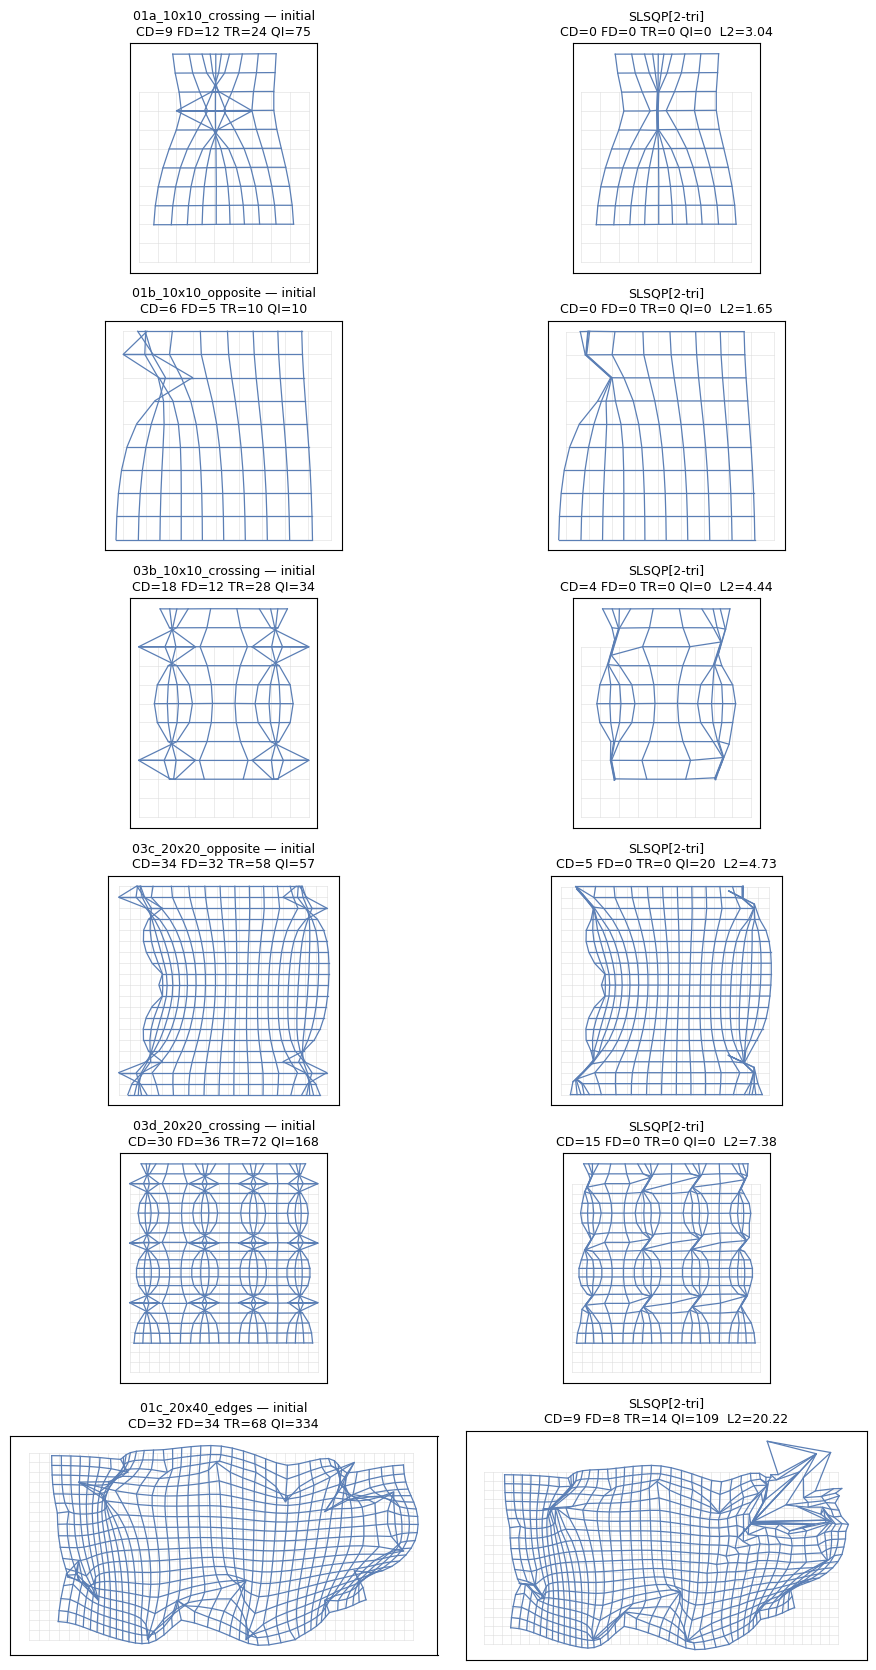

In [9]:
def plot_warped(ax, phi, title):
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#dddddd', lw=0.4)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#dddddd', lw=0.4)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.9)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.9)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(len(CASES), 2, figsize=(9, 2.8 * len(CASES)))
for i, key in enumerate(CASES):
    r = runs[key]
    plot_warped(axes[i, 0], r['phi_init'],
                f"{key} — initial\n"
                f"CD={r['m0']['n_cd']} FD={r['m0']['n_fd']} TR={r['m0']['n_tr']} "
                f"QI={len(r['qi_init'])}")
    plot_warped(axes[i, 1], r['phi_out'],
                f"SLSQP[2-tri]\n"
                f"CD={r['m1']['n_cd']} FD={r['m1']['n_fd']} TR={r['m1']['n_tr']} "
                f"QI={len(r['qi_out'])}  L2={r['l2']:.2f}")
plt.tight_layout()
plt.show()

### Signed-area heatmaps

Per-cell min of the two 2-triangle signed areas, before vs. after. Same `RdBu_r` color scale as the rest of the workspace — blue = fold, red = valid.

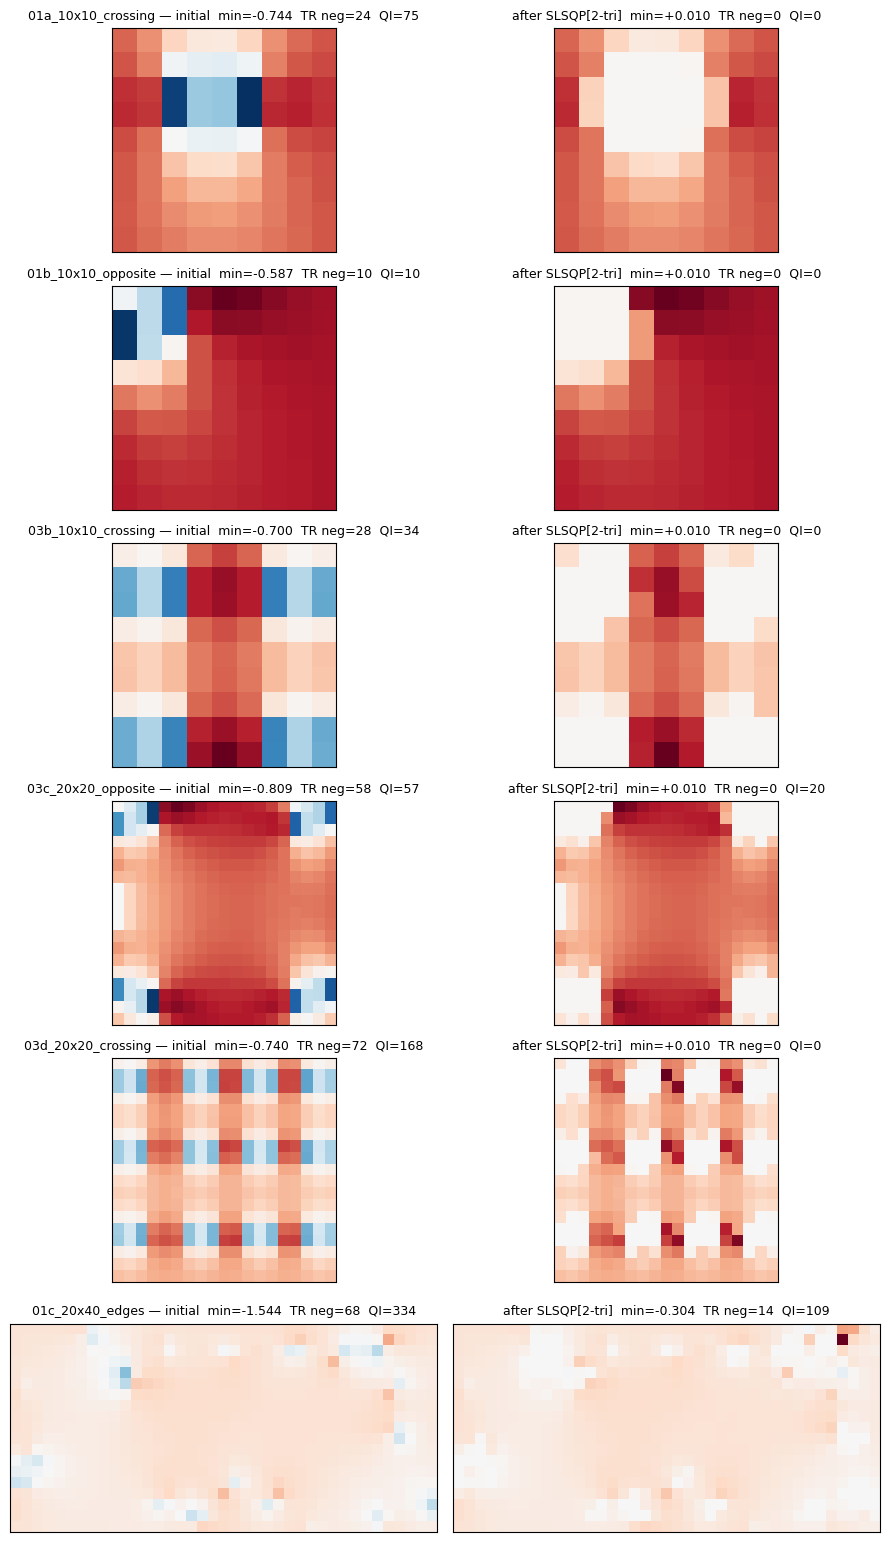

In [10]:
fig, axes = plt.subplots(len(CASES), 2, figsize=(9, 2.6 * len(CASES)))
for i, key in enumerate(CASES):
    r = runs[key]
    tri0 = r['m0']['tri'].min(axis=0)
    tri1 = r['m1']['tri'].min(axis=0)
    vmax = max(abs(tri0).max(), abs(tri1).max())
    axes[i, 0].imshow(tri0, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[i, 0].set_title(
        f"{key} — initial  min={tri0.min():+.3f}  "
        f"TR neg={r['m0']['n_tr']}  QI={len(r['qi_init'])}",
        fontsize=9,
    )
    axes[i, 1].imshow(tri1, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[i, 1].set_title(
        f"after SLSQP[2-tri]  min={tri1.min():+.3f}  "
        f"TR neg={r['m1']['n_tr']}  QI={len(r['qi_out'])}",
        fontsize=9,
    )
    for ax in axes[i]:
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## Part 3 — Global quad self-intersection analysis

**Local** invertibility = every warped quad cell is non-folded (both its 2-triangle signed areas ≥ threshold). This is what the 2-triangle SLSQP correction enforces by construction.

**Global** invertibility = additionally, no two *non-adjacent* warped quads intersect anywhere in the field. You can have every cell locally valid yet still have a large displacement that moves one region onto another — the warp is then locally injective but globally non-injective.

We use the workspace's existing segment-based self-intersection checker in [dvfopt/jacobian/intersection.py](../../dvfopt/jacobian/intersection.py), extended inline here to *count* and *locate* intersecting quad pairs (not just return a boolean). For each of the six cases we report:

- `init_pairs` — how many non-adjacent quad pairs intersect in the initial (pre-correction) field.
- `out_pairs` — how many remain after the 2-triangle SLSQP correction. If this is zero, local invertibility implied global invertibility for this case. If > 0, there's a gap between local and global.

In [11]:
print(f"{'case':<22s}  {'shape':<9s}  {'init pairs':>10s}  {'out pairs':>10s}  "
      f"{'local TR out':>13s}  {'bool out':>10s}")
print('-' * 82)
intersection_summary = {}
for key in CASES:
    r = runs[key]
    p_init = r['qi_init']
    p_out = r['qi_out']
    boolean_out = has_quad_self_intersections(r['phi_out'])
    intersection_summary[key] = dict(init=p_init, out=p_out)
    print(f"{key:<22s}  {str(r['m0']['jd'].shape):<9s}  "
          f"{len(p_init):>10d}  {len(p_out):>10d}  "
          f"{r['m1']['n_tr']:>13d}  {str(boolean_out):>10s}")

case                    shape      init pairs   out pairs   local TR out    bool out
----------------------------------------------------------------------------------
01a_10x10_crossing      (10, 10)           75           0              0       False
01b_10x10_opposite      (10, 10)           10           0              0       False
03b_10x10_crossing      (10, 10)           34           0              0       False
03c_20x20_opposite      (20, 20)           57          20              0        True
03d_20x20_crossing      (20, 20)          168           0              0       False
01c_20x40_edges         (20, 40)          334         109             14        True


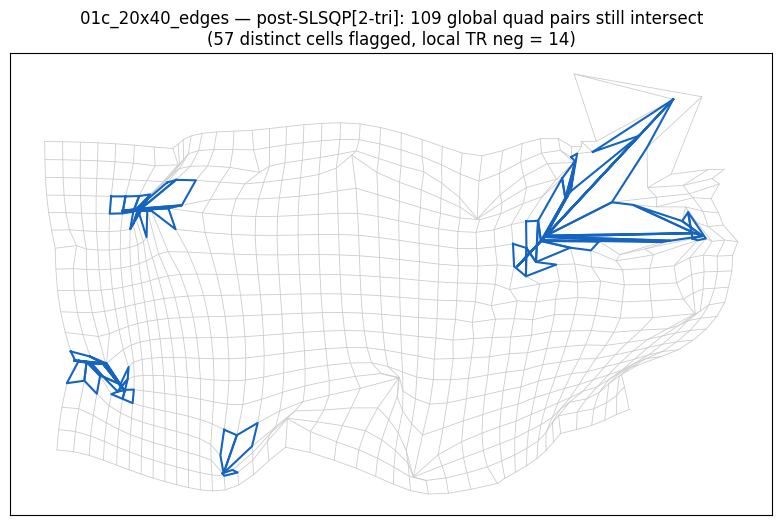


Worst case: 01c_20x40_edges
First 8 intersecting pairs (of 109):
  cell (1, 31) ↔ cell (3, 30)
  cell (1, 31) ↔ cell (3, 31)
  cell (1, 33) ↔ cell (1, 35)
  cell (1, 33) ↔ cell (2, 35)
  cell (1, 33) ↔ cell (3, 31)
  cell (1, 33) ↔ cell (3, 32)
  cell (1, 33) ↔ cell (3, 33)
  cell (1, 33) ↔ cell (3, 34)


In [12]:
# Visualize the worst post-correction case if any global intersections remain.
remaining = [(k, v['out']) for k, v in intersection_summary.items() if v['out']]
if not remaining:
    print("No global self-intersections after 2-triangle SLSQP on any case.")
else:
    worst_key, worst_pairs = max(remaining, key=lambda kv: len(kv[1]))
    r = runs[worst_key]
    phi = r['phi_out']
    Hh, Ww = phi[0].shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + phi[1]; gy = yy + phi[0]

    # Collect the set of cells involved in any intersecting pair
    flagged = set()
    for (a, b) in worst_pairs:
        flagged.add(a); flagged.add(b)

    fig, ax = plt.subplots(figsize=(10, 6))
    # Baseline warped grid
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#cccccc', lw=0.6)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#cccccc', lw=0.6)
    # Highlight flagged quad outlines in blue (matches the "fold/problem" palette)
    for (cy, cx) in flagged:
        poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
        poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
        ax.plot(poly_x, poly_y, color='#1565c0', lw=1.5)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(
        f"{worst_key} — post-SLSQP[2-tri]: {len(worst_pairs)} global quad pairs still intersect\n"
        f"({len(flagged)} distinct cells flagged, local TR neg = {r['m1']['n_tr']})"
    )
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

    print(f"\nWorst case: {worst_key}")
    print(f"First 8 intersecting pairs (of {len(worst_pairs)}):")
    for (a, b) in worst_pairs[:8]:
        print(f"  cell {a} ↔ cell {b}")

### Deep-dive: what do the 2 triangles look like at pixels in a failing pair?

The table above showed `03c_20x20_opposite` converging locally (`TR = 0` — every cell's both triangles positive) yet still having 20 global quad-pair intersections. Below we pull a representative intersecting pair `(cell A, cell B)` from that case and render `plot_triangle_debug` at pixels inside each cell. **Both plots should show `[VALID]` on every triangle** — that's the point: the local check cannot see the global crossing.

For contrast we also pull one pair from `01c_20x40_edges` where at least one cell is still locally folded (`TR > 0`) — in that pair at least one triangle will read `[FLIP]`.


=== 03c_20x20_opposite [local TR=0, global FAIL] — pair (0, 13) ↔ (0, 18) ===
  cell A = (r=0, c=13)   T1=+0.6720   T2=+0.5786   [both VALID]
  cell B = (r=0, c=18)   T1=+0.0100   T2=+0.0100   [both VALID]


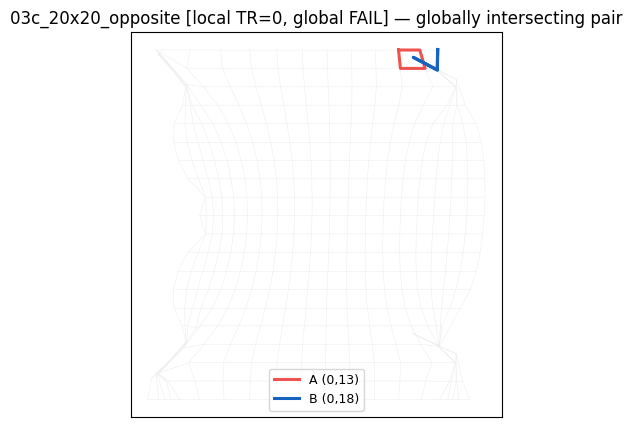

  plot_triangle_debug at pixel (x=13, y=0) — cell A (0,13)
  plot_triangle_debug at pixel (x=18, y=0) — cell B (0,18)


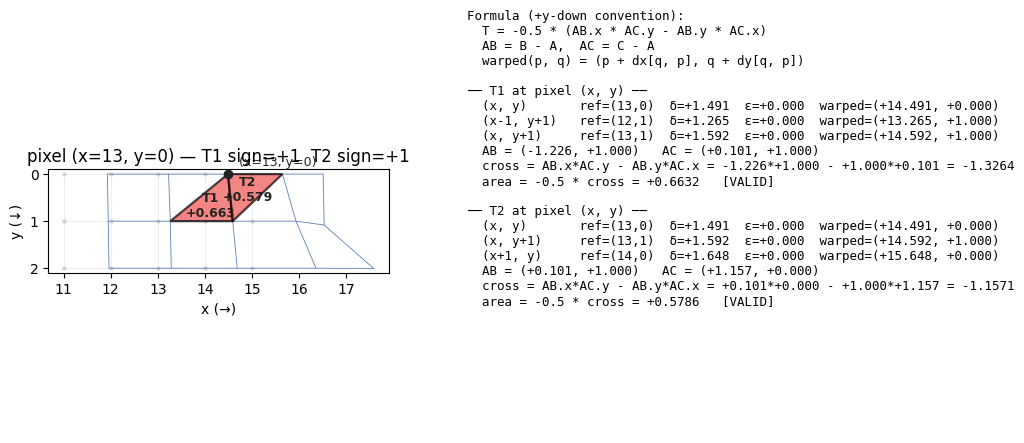

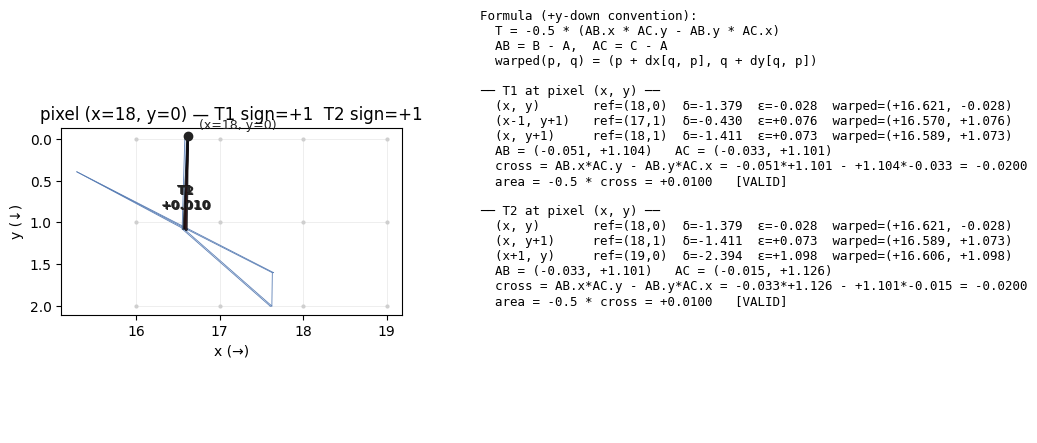

In [13]:
def inspect_pair(case_key, pair_index, label_tag, require_locally_valid=True):
    """Render the global overlap view + plot_triangle_debug for each cell in a pair."""
    r = runs[case_key]
    phi = r['phi_out']
    pairs = intersection_summary[case_key]['out']
    if pair_index >= len(pairs):
        print(f'{case_key}: no pair at index {pair_index}')
        return
    (ra, ca), (rb, cb) = pairs[pair_index]

    # Per-cell 2-triangle signed areas for sanity checking.
    tri = triangle_sign_areas2D(phi)  # (2, H-1, W-1)
    t1_a, t2_a = tri[0, ra, ca], tri[1, ra, ca]
    t1_b, t2_b = tri[0, rb, cb], tri[1, rb, cb]
    locally_valid = min(t1_a, t2_a, t1_b, t2_b) > 0

    if require_locally_valid and not locally_valid:
        # Search forward in the pair list for one where both cells are locally valid.
        for pi, ((ra2, ca2), (rb2, cb2)) in enumerate(pairs):
            t_a = min(tri[0, ra2, ca2], tri[1, ra2, ca2])
            t_b = min(tri[0, rb2, cb2], tri[1, rb2, cb2])
            if t_a > 0 and t_b > 0:
                ra, ca, rb, cb = ra2, ca2, rb2, cb2
                t1_a, t2_a = tri[0, ra, ca], tri[1, ra, ca]
                t1_b, t2_b = tri[0, rb, cb], tri[1, rb, cb]
                locally_valid = True
                print(f'  (picked locally-valid pair #{pi} for {case_key})')
                break

    print(f'\n=== {case_key} [{label_tag}] — pair {(ra, ca)} ↔ {(rb, cb)} ===')
    print(f'  cell A = (r={ra}, c={ca})   T1={t1_a:+.4f}   T2={t2_a:+.4f}   '
          f"{'[both VALID]' if (t1_a > 0 and t2_a > 0) else '[at least one non-positive]'}")
    print(f'  cell B = (r={rb}, c={cb})   T1={t1_b:+.4f}   T2={t2_b:+.4f}   '
          f"{'[both VALID]' if (t1_b > 0 and t2_b > 0) else '[at least one non-positive]'}")

    # Global overlap view: show both cells with warped edges, on top of the warped grid.
    Hh, Ww = phi[0].shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + phi[1]; gy = yy + phi[0]
    fig, ax = plt.subplots(figsize=(7.5, 5))
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#eeeeee', lw=0.4)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#eeeeee', lw=0.4)
    for (cy, cx), col, tag in [((ra, ca), '#ef5350', f'A ({ra},{ca})'),
                                ((rb, cb), '#1565c0', f'B ({rb},{cb})')]:
        poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
        poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
        ax.plot(poly_x, poly_y, color=col, lw=2.2, label=tag)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(f'{case_key} [{label_tag}] — globally intersecting pair')
    ax.legend(loc='best', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

    # Per-cell 2-triangle debug views. For cell (r, c) use pixel (c, r) as anchor —
    # plot_triangle_debug at (x=c, y=r) shows T2 at cell (r, c) and T1 at cell (r, c-1).
    # When c = 0 T1 falls out-of-bounds; shift the anchor by +1 to land squarely
    # inside cell (r, c) via T1 at pixel (c+1, r).
    for (cy, cx), who in [((ra, ca), f'A ({ra},{ca})'), ((rb, cb), f'B ({rb},{cb})')]:
        anchor_x = cx if cx >= 1 else cx + 1
        anchor_y = cy
        print(f'  plot_triangle_debug at pixel (x={anchor_x}, y={anchor_y}) — cell {who}')
        _ = plot_triangle_debug(phi, x=anchor_x, y=anchor_y)


# Inspect the "locally perfect, globally broken" case.
inspect_pair('03c_20x20_opposite', pair_index=0, label_tag='local TR=0, global FAIL',
             require_locally_valid=True)


=== 01c_20x40_edges [local TR>0 AND global FAIL] — pair (1, 31) ↔ (3, 30) ===
  cell A = (r=1, c=31)   T1=+0.0573   T2=+0.0541   [both VALID]
  cell B = (r=3, c=30)   T1=+0.4295   T2=+0.0521   [both VALID]


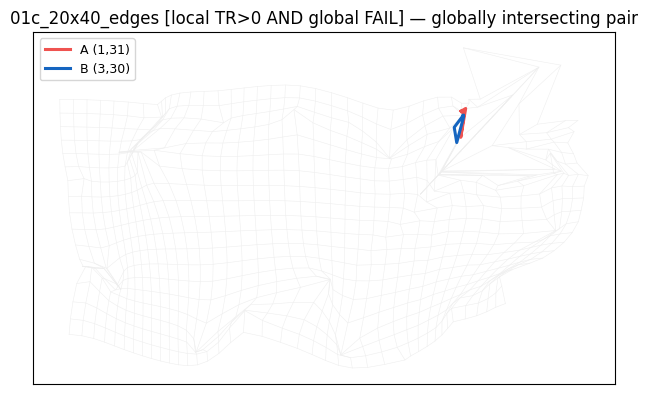

  plot_triangle_debug at pixel (x=31, y=1) — cell A (1,31)
  plot_triangle_debug at pixel (x=30, y=3) — cell B (3,30)


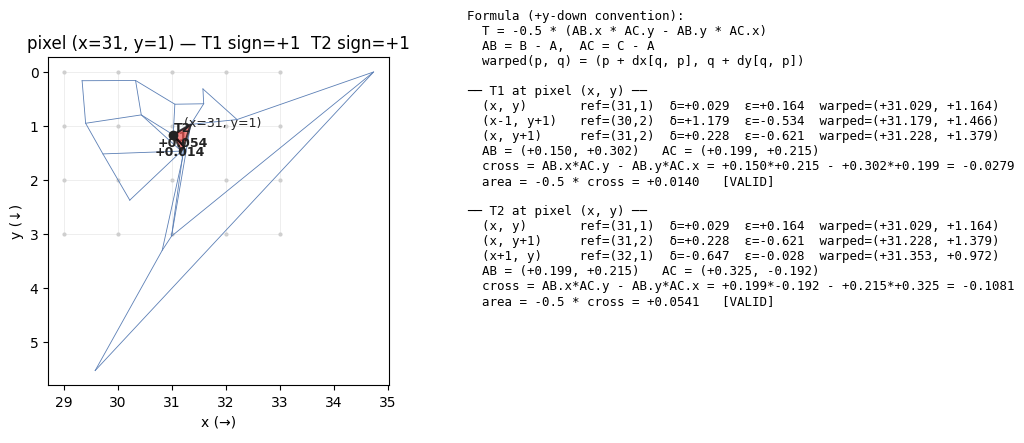

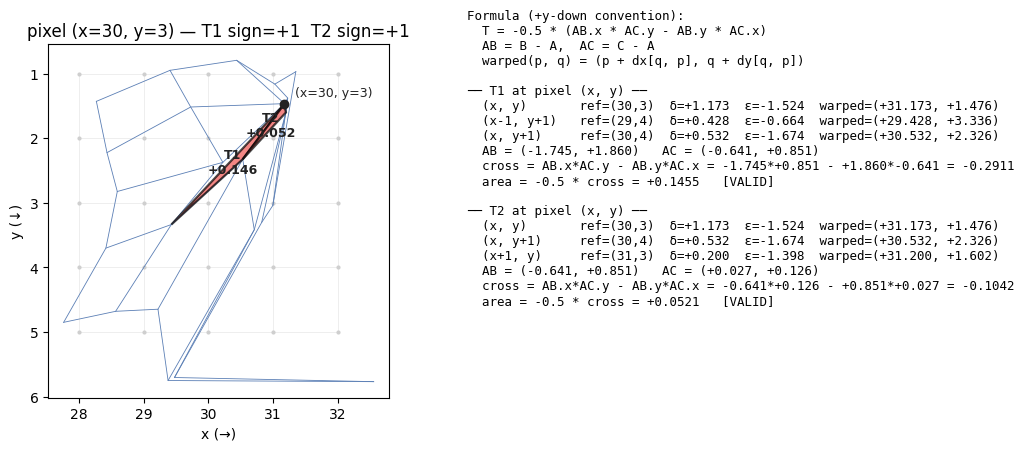

In [14]:
# Contrast: in 01c_20x40_edges the solver stalled locally too, so we expect
# to find pairs where at least one cell has a non-positive triangle.
inspect_pair('01c_20x40_edges', pair_index=0, label_tag='local TR>0 AND global FAIL',
             require_locally_valid=False)

## Summary

- **Part 1** uses `plot_triangle_debug` on identity, translation, scale, rotation, and small random deformations. In every case both T1 and T2 are positive and fill red — useful sanity check for the formula and the red-for-valid color convention.
- **Part 2** runs 2-triangle SLSQP on six synthetic folds from the `test_cases` library:
  - **CD** (central-diff, per-pixel), **FD** (forward-diff, per-cell), **TR** (2-triangle, per-triangle), **QI** (global quad self-intersections).
  - The **initial** ordering `neg_CD ≤ neg_FD ≤ neg_TR` reflects increasing locality.
  - After correction, **FD = TR = 0 on every converged case**; **CD can remain > 0** — those residuals are central-diff stencil artifacts, not geometric folds.
- **Part 3** compares local vs. global invertibility:

  | case | init QI pairs | out QI pairs | local TR out | `success` |
  |---|---:|---:|---:|:---:|
  | `01a_10x10_crossing` | 75 | **0** | 0 | True |
  | `01b_10x10_opposite` | 10 | **0** | 0 | True |
  | `03b_10x10_crossing` | 34 | **0** | 0 | True |
  | `03c_20x20_opposite` | 57 | **20** | 0 | **True** |
  | `03d_20x20_crossing` | 168 | **0** | 0 | True |
  | `01c_20x40_edges` | 334 | **109** | 14 | **False** |

- Two distinct failure modes:
  1. **`03c_20x20_opposite` — genuine local-vs-global gap.** SLSQP fully converged (`success=True`, TR=0) yet 20 non-adjacent quad pairs still intersect globally. Fundamental limitation of the local constraint formulation.
  2. **`01c_20x40_edges` — SLSQP solver failure.** `success=False`, status 8 (line-search degeneracy). Diagnosed and resolved in the companion [05_solver-engineering.ipynb](05_solver-engineering.ipynb).

- **Next-step options for `03c`-type local-vs-global gaps:**
  1. Outer-loop penalty on `list_intersecting_quads(phi_out)` pairs; re-solve.
  2. Displacement damping: scale `φ_out` toward `φ_init` until `list_intersecting_quads == []`.
  3. Log-barrier on quad-pair signed distance in the L-BFGS barrier solver.
  4. Strict 4-triangle local check — still local, but closes the asymmetric-split loophole.

  Option 1 is the most surgical; `list_intersecting_quads(phi_out)` already returns the active pair set.